In [10]:
!pip install tensorflow tensorflow-hub matplotlib pillow

In [11]:
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [12]:
import os
print(os.listdir())

['.config', '.ipynb_checkpoints', 'style.jpeg', 'content.jpeg', 'sample_data']


In [13]:
def load_image(path):
    img = Image.open(path).convert("RGB")
    img = img.resize((512, 512))
    img = np.array(img).astype(np.float32) / 255.0
    img = tf.convert_to_tensor(img)
    img = tf.expand_dims(img, axis=0)
    return img

content_image = load_image("content.jpeg")
style_image = load_image("style.jpeg")

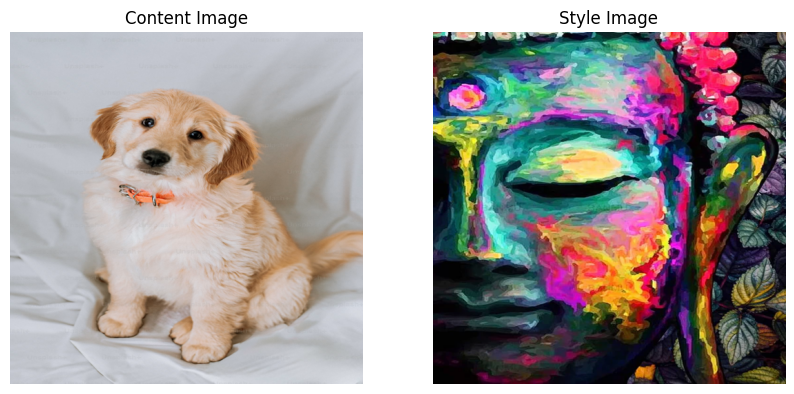

In [14]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(content_image[0])
plt.title("Content Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(style_image[0])
plt.title("Style Image")
plt.axis("off")

plt.show()

In [15]:
model = hub.load("https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2")

In [16]:
stylized_image = model(
    tf.constant(content_image),
    tf.constant(style_image)
)[0]

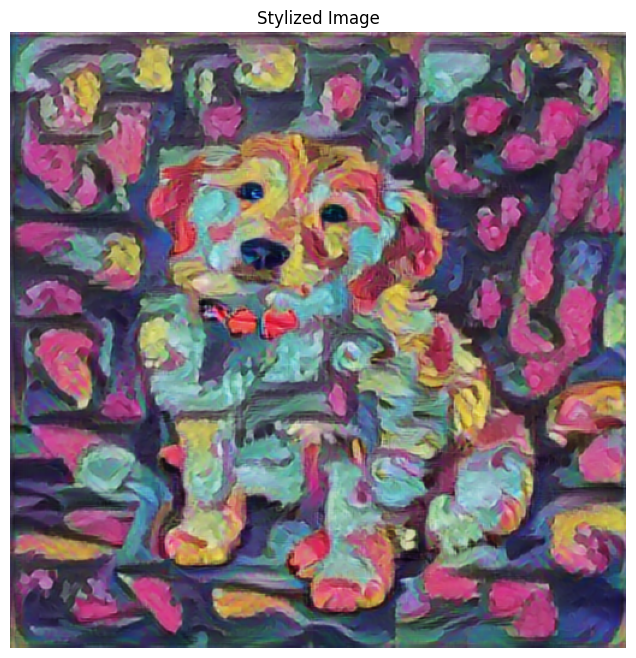

In [17]:
plt.figure(figsize=(8,8))
plt.imshow(tf.squeeze(stylized_image))
plt.title("Stylized Image")
plt.axis("off")
plt.show()

In [18]:
import matplotlib.pyplot as plt

plt.imsave("stylized_output.jpg", tf.squeeze(stylized_image))